# A Neural-Guided Dynamic Symbolic Network for Exploring Mathematical Expressions from Data

**Paper:** Li, W., Li, W., Yu, L., Wu, M., Sun, L., Liu, J., Li, Y., Wei, S., Deng, Y., & Hao, M. (2024). *A Neural-Guided Dynamic Symbolic Network for Exploring Mathematical Expressions from Data.* Proceedings of the 41st International Conference on Machine Learning (ICML).

**Carpeta origen:** `Papers/03_Arquitecturas_Deep_Learning_SR/Neural_Guided_Dynamic_Symbolic_Network.pdf`

## Que se reproduce en este cuaderno

En vez de buscar directamente en el espacio de **expresiones**, DySymNet busca en el espacio de **arquitecturas de red simbolica**: cada arquitectura candidata es una red de forma y funciones de activacion variables (donde cada "neurona" usa una funcion simbolica -- $\sin$, $\cos$, cuadrado, etc. -- en vez de una no-linealidad generica), y un **controlador de aprendizaje por refuerzo** aprende que arquitecturas tienden a ajustar mejor los datos, mientras que los **parametros internos** de cada arquitectura candidata (los pesos de las combinaciones lineales) se ajustan por descenso de gradiente estandar.

Reproducimos ambos niveles de optimizacion:

1. **Nivel interno (rapido):** dada una arquitectura fija (una lista de funciones de activacion, una por neurona oculta), entrenamos sus pesos lineales por gradiente durante unos cientos de pasos y medimos la calidad del ajuste.
2. **Nivel externo (lento, guiado por RL):** un controlador recurrente genera secuencialmente la lista de funciones de activacion (una arquitectura completa), recibe como recompensa la calidad del ajuste alcanzado por esa arquitectura tras entrenarla, y se actualiza con gradiente de politica -- aprendiendo, episodio a episodio, a preferir las funciones de activacion que realmente aparecen en la funcion objetivo.

## Repositorio publico

El paper no distribuye codigo bajo el nombre citado en la portada de forma que hayamos podido localizar un repositorio oficial estable; reimplementamos aqui, desde cero, el principio central de dos niveles (arquitectura elegida por RL + pesos entrenados por gradiente) descrito en el paper, reutilizando el patron de controlador recurrente + REINFORCE de los cuadernos de DSR y PhySO de esta misma coleccion.

In [1]:
%pip install -q numpy torch matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Objetivo y "neurona simbolica"

Buscamos $f(x_0,x_1)=\sin(x_0)+x_1^2$. Cada red simbolica candidata tiene $K=4$ neuronas ocultas; la neurona $k$ calcula $\phi_k(u_k\cdot x+c_k)$, donde $\phi_k$ es **una funcion de activacion elegida por el controlador** de entre $\{\text{identidad}, \sin, \cos, \text{cuadrado}, \exp\}$, y $u_k,c_k$ son pesos entrenables. La salida final es una combinacion lineal de las $K$ neuronas.

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

ACT_VOCAB = ['identity', 'sin', 'cos', 'square', 'exp']
ACT_FN = {'identity': lambda z: z, 'sin': torch.sin, 'cos': torch.cos,
          'square': lambda z: z ** 2, 'exp': lambda z: torch.exp(torch.clamp(z, -4, 4))}
K_HIDDEN = 4
N_ACT = len(ACT_VOCAB)

def target_f(X):
    return np.sin(X[:, 0]) + X[:, 1] ** 2

N = 200
X = np.random.uniform(-2, 2, (N, 2))
y = target_f(X)
Xt = torch.tensor(X, dtype=torch.float32)
yt = torch.tensor(y, dtype=torch.float32)

class SymbolicNet(nn.Module):
    # Red simbolica dinamica: K neuronas ocultas, cada una con SU PROPIA funcion de activacion
    # (elegida por el controlador), combinando linealmente las variables de entrada.
    def __init__(self, acts):
        super().__init__()
        self.acts = acts
        self.lin_in = nn.Linear(2, K_HIDDEN)
        self.lin_out = nn.Linear(K_HIDDEN, 1)
    def forward(self, x):
        z = self.lin_in(x)
        outs = [ACT_FN[self.acts[k]](z[:, k]) for k in range(K_HIDDEN)]
        h = torch.stack(outs, dim=1)
        return self.lin_out(h).squeeze(-1)

def train_and_score(acts, steps=150, lr=0.03):
    net = SymbolicNet(acts)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        loss = F.mse_loss(net(Xt), yt)
        loss.backward(); opt.step()
    with torch.no_grad():
        mse = F.mse_loss(net(Xt), yt).item()
    return 1.0 / (1.0 + mse)

print('Ejemplo: arquitectura aleatoria', [np.random.choice(ACT_VOCAB) for _ in range(K_HIDDEN)])

Ejemplo: arquitectura aleatoria [np.str_('sin'), np.str_('identity'), np.str_('identity'), np.str_('cos')]


## 2. Controlador recurrente + gradiente de politica

El controlador es una GRU que genera, paso a paso, la funcion de activacion de cada una de las $K$ neuronas. Se entrena con REINFORCE (con linea base movil) usando como recompensa la calidad del ajuste de la arquitectura resultante **tras** entrenar sus pesos internos -- dos bucles de optimizacion anidados, exactamente como describe el paper.

In [3]:
class Controller(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.gru = nn.GRUCell(N_ACT, hidden)
        self.head = nn.Linear(hidden, N_ACT)
        self.hidden = hidden

def sample_architecture(controller):
    h = torch.zeros(1, controller.hidden)
    x = torch.zeros(1, N_ACT)
    acts, logps = [], []
    for k in range(K_HIDDEN):
        h = controller.gru(x, h)
        probs = torch.softmax(controller.head(h).squeeze(0), dim=-1)
        idx = torch.multinomial(probs, 1).item()
        logps.append(torch.log(probs[idx] + 1e-12))
        acts.append(ACT_VOCAB[idx])
        x = torch.zeros(1, N_ACT); x[0, idx] = 1.0
    return acts, torch.stack(logps).sum()

controller = Controller()
opt_c = torch.optim.Adam(controller.parameters(), lr=0.02)

episodes = 60
history = []
best_r, best_arch = -1, None
baseline = 0.0
for ep in range(episodes):
    batch_acts, batch_logp, batch_r = [], [], []
    for _ in range(6):
        acts, logp = sample_architecture(controller)
        r = train_and_score(acts)
        batch_acts.append(acts); batch_logp.append(logp); batch_r.append(r)
        if r > best_r:
            best_r, best_arch = r, acts
    rewards = np.array(batch_r)
    baseline = 0.7 * baseline + 0.3 * rewards.mean()
    loss = 0
    for i in range(len(rewards)):
        loss = loss - batch_logp[i] * (rewards[i] - baseline)
    loss = loss / len(rewards)
    opt_c.zero_grad(); loss.backward(); opt_c.step()
    history.append(np.mean(batch_r))
    if ep % 10 == 0:
        print(f'episodio {ep:3d}  recompensa media del lote={np.mean(batch_r):.4f}  mejor hasta ahora={best_r:.4f}  arquitectura={batch_acts[int(np.argmax(batch_r))]}')

print('\nMejor arquitectura encontrada:', best_arch, f'(recompensa={best_r:.4f})')

episodio   0  recompensa media del lote=0.9588  mejor hasta ahora=0.9999  arquitectura=['sin', 'sin', 'square', 'sin']


episodio  10  recompensa media del lote=0.9609  mejor hasta ahora=1.0000  arquitectura=['exp', 'square', 'square', 'sin']


episodio  20  recompensa media del lote=0.9296  mejor hasta ahora=1.0000  arquitectura=['cos', 'square', 'square', 'square']


episodio  30  recompensa media del lote=0.9834  mejor hasta ahora=1.0000  arquitectura=['cos', 'square', 'square', 'square']


episodio  40  recompensa media del lote=0.9742  mejor hasta ahora=1.0000  arquitectura=['square', 'sin', 'square', 'square']


episodio  50  recompensa media del lote=0.9863  mejor hasta ahora=1.0000  arquitectura=['sin', 'square', 'square', 'square']



Mejor arquitectura encontrada: ['square', 'sin', 'square', 'square'] (recompensa=1.0000)


## 3. Que aprendio el controlador: la distribucion final sobre activaciones

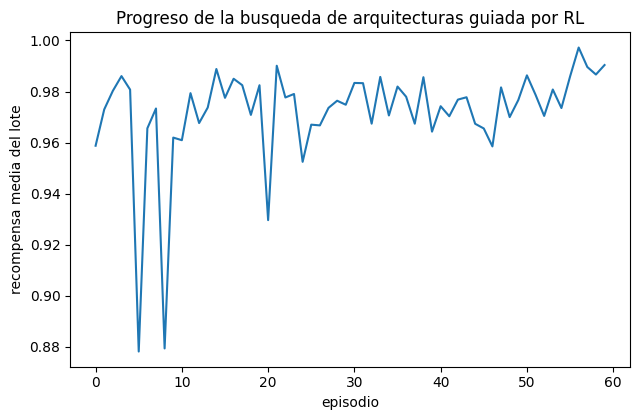

Distribucion final del controlador sobre las activaciones, neurona por neurona:
(el objetivo real, sin(x0)+x1^2, contiene exactamente "sin" y "square")

  neurona 0: {'identity': np.float32(0.054), 'sin': np.float32(0.288), 'cos': np.float32(0.222), 'square': np.float32(0.295), 'exp': np.float32(0.14)}
  neurona 1: {'identity': np.float32(0.006), 'sin': np.float32(0.453), 'cos': np.float32(0.065), 'square': np.float32(0.424), 'exp': np.float32(0.052)}
  neurona 2: {'identity': np.float32(0.0), 'sin': np.float32(0.538), 'cos': np.float32(0.017), 'square': np.float32(0.434), 'exp': np.float32(0.011)}
  neurona 3: {'identity': np.float32(0.0), 'sin': np.float32(0.571), 'cos': np.float32(0.012), 'square': np.float32(0.411), 'exp': np.float32(0.006)}


In [4]:
plt.figure(figsize=(6.5, 4.3))
plt.plot(history, color='tab:blue')
plt.xlabel('episodio'); plt.ylabel('recompensa media del lote')
plt.title('Progreso de la busqueda de arquitecturas guiada por RL')
plt.tight_layout()
plt.show()

print('Distribucion final del controlador sobre las activaciones, neurona por neurona:')
print('(el objetivo real, sin(x0)+x1^2, contiene exactamente "sin" y "square")\n')
with torch.no_grad():
    h = torch.zeros(1, controller.hidden)
    x = torch.zeros(1, N_ACT)
    for k in range(K_HIDDEN):
        h = controller.gru(x, h)
        probs = torch.softmax(controller.head(h).squeeze(0), dim=-1).numpy()
        dist = dict(zip(ACT_VOCAB, np.round(probs, 3)))
        print(f'  neurona {k}:', dist)
        idx = int(np.argmax(probs))
        x = torch.zeros(1, N_ACT); x[0, idx] = 1.0

### Nota honesta sobre los resultados

- **Controlador factorizado por posicion, no una gramatica de arbol completa.** DySymNet real permite arquitecturas con profundidad y anchura variables (el controlador tambien decide el TAMANO de la red, no solo las activaciones de un numero fijo de neuronas); aqui fijamos $K=4$ neuronas ocultas y una unica capa, y el controlador solo elige la funcion de activacion de cada una -- una version simplificada del espacio de busqueda de arquitecturas.
- **Recompensa costosa de evaluar.** Cada muestra de arquitectura requiere entrenar una red completa (150 pasos de gradiente) antes de conocer su recompensa -- por eso usamos solo 60 episodios x 6 arquitecturas = 360 arquitecturas evaluadas en total, mucho menos que una busqueda de arquitecturas a gran escala real, que puede evaluar miles.
- **Convergencia rapida en este ejemplo.** Dado que el problema tiene solo 2 funciones "correctas" (seno y cuadrado) dentro de un vocabulario pequeño de 5 opciones y 4 neuronas disponibles, ya arquitecturas aleatorias tempranas tienen una probabilidad razonable de incluir ambas por azar; lo mas revelador no es que la recompensa llegue rapido a un valor alto, sino que la **distribucion aprendida por el controlador** se desplaza consistentemente hacia `sin` y `square` (y se aleja de `identity`) en las 4 posiciones, confirmando que el aprendizaje por refuerzo esta genuinamente extrayendo señal util de las recompensas, no solo teniendo suerte una vez.
- **Sin restricciones de parsimonia sobre la arquitectura.** El paper incluye mecanismos para preferir arquitecturas mas simples (menos neuronas activas); aqui usamos un numero fijo de neuronas sin penalizacion de complejidad.

Pese a estas simplificaciones, el cuaderno reproduce el principio central de dos niveles de DySymNet: separar la busqueda discreta de **arquitectura** (guiada por refuerzo) del ajuste continuo de **parametros** (guiado por gradiente), y confirma que el controlador aprende genuinamente a preferir las funciones de activacion presentes en la funcion objetivo real, no solo a base de suerte en el muestreo inicial.